In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch

In [2]:
# Load world countries directly
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [3]:
zambia = world[world["NAME"] == "Zambia"]

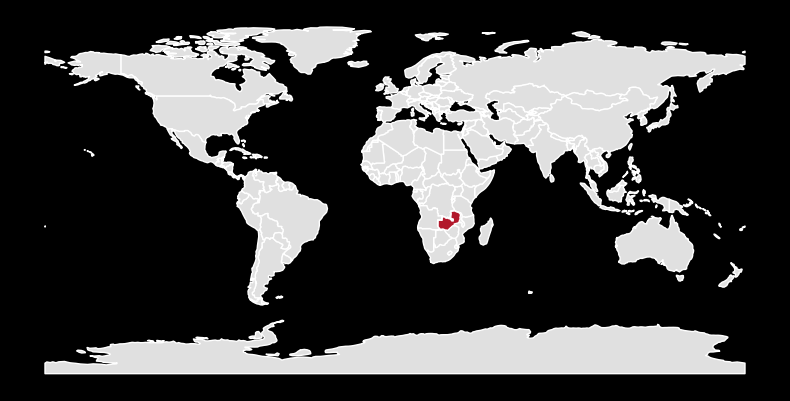

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

world.plot(ax=ax, color="#e0e0e0", edgecolor="white")
zambia.plot(ax=ax, color="#b2182b")

ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    "../figures/zambia_world_map.pdf",
    format="pdf",
    bbox_inches="tight"
)

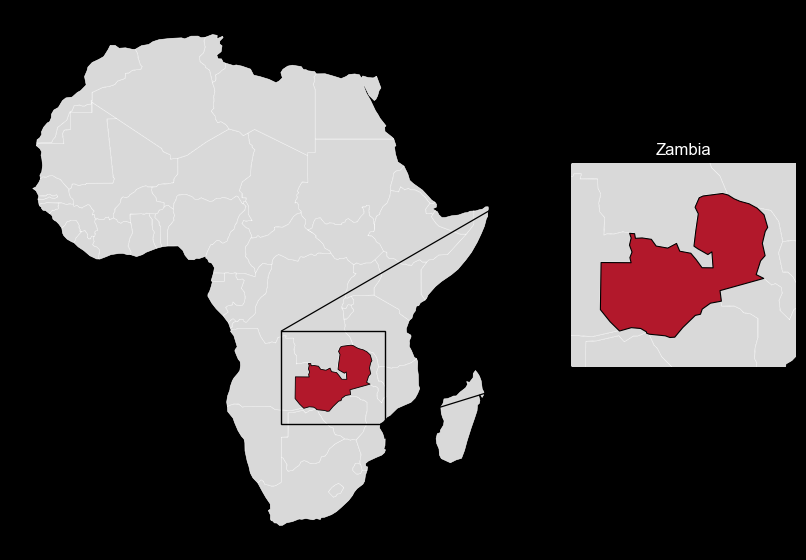

In [5]:
name_col = "NAME" if "NAME" in world.columns else "ADMIN"

africa = world[world["CONTINENT"] == "Africa"]
zambia = world[world[name_col] == "Zambia"]

AFRICA_COLOR = "#d9d9d9"
ZMB_COLOR = "#b2182b"

fig = plt.figure(figsize=(9,6))

# --- Main Africa map ---
ax_main = fig.add_axes([0.05, 0.05, 0.65, 0.9])
africa.plot(ax=ax_main, color=AFRICA_COLOR, edgecolor="white", linewidth=0.4)
zambia.plot(ax=ax_main, color=ZMB_COLOR, edgecolor="black", linewidth=0.6)

ax_main.set_axis_off()
# ax_main.set_title("Zambia within Africa", fontsize=12)

# --- Zambia zoom inset ---
ax_inset = fig.add_axes([0.72, 0.35, 0.25, 0.35])

xmin, ymin, xmax, ymax = zambia.total_bounds
buffer = 2

ax_inset.set_xlim(xmin-buffer, xmax+buffer)
ax_inset.set_ylim(ymin-buffer, ymax+buffer)

africa.plot(ax=ax_inset, color=AFRICA_COLOR, edgecolor="white", linewidth=0.4)
zambia.plot(ax=ax_inset, color=ZMB_COLOR, edgecolor="black", linewidth=0.8)

ax_inset.set_axis_off()
ax_inset.set_title("Zambia", fontsize=12)

# --- Draw zoom rectangle on Africa map ---
rect = Rectangle(
    (xmin-buffer, ymin-buffer),
    (xmax-xmin) + 2*buffer,
    (ymax-ymin) + 2*buffer,
    fill=False,
    edgecolor="black",
    linewidth=1
)
ax_main.add_patch(rect)

# --- Add connector line ---
con_top = ConnectionPatch(
    xyA=(xmin-buffer, ymax+buffer), coordsA=ax_main.transData,
    xyB=(xmin-buffer, ymax+buffer), coordsB=ax_inset.transData,
    color="black",
    linewidth=0.9
)
fig.add_artist(con_top)

con_bottom = ConnectionPatch(
    xyA=(xmax+buffer, ymin-buffer), coordsA=ax_main.transData,   # right-bottom of box
    xyB=(xmin-buffer, ymin-buffer), coordsB=ax_inset.transData, # left-bottom of inset
    color="black",
    linewidth=0.9
)
fig.add_artist(con_bottom)


# Save as vector PDF
fig.savefig("../figures/zambia_africa_map.pdf", format="pdf", bbox_inches="tight")

plt.show()